In [9]:
import re

M_RE = re.compile(r"M(?P<M>\d+)")
PS_RE = re.compile(r"ps(?P<ps>\d+)")


def parse_dir_name(dirname: str) -> dict:

    parts = dirname.split("__")
    if len(parts) < 4:
        raise ValueError(f"Unexpected run dir name format: {dirname}")

    train_ds = parts[0]          # e.g. 'msmarco-passage-train'
    model_name = parts[1]        # e.g. 'tct_colbert'
    pq_impl = parts[2]           # e.g. 'faiss2opq'
    M = parts[3]                 # e.g. 'M48'
    ps = parts[4]                # e.g. 'ps100000'

    m_match = M_RE.search(M)
    M = int(m_match.group("M"))
    ps_match = PS_RE.search(ps)
    ps = int(ps_match.group("ps"))

    return {
        "train_ds": train_ds,
        "model": model_name,
        "pq_impl": pq_impl,
        "M": M,
        "ps": ps,
    }

In [10]:
import pandas as pd
from pathlib import Path

def load_single_metrics_csv(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, index_col=0)
    if "name" not in df.columns:
        raise ValueError(f"'name' column not found in {csv_path}")
    return df

In [13]:
import numpy as np

def collect_all_results(root: Path, split: str = '2019') -> pd.DataFrame:
    rows = []

    for run_dir in root.iterdir():
        if not run_dir.is_dir():
            continue

        metrics_path = run_dir / "runs" / ("test-" + split) / "metrics.csv"
        if not metrics_path.is_file():
            continue
       
        try:
            meta = parse_dir_name(run_dir.name)
        except ValueError as e:
            # skip dirs that do not follow naming convention
            print(f"[WARN] Skipping {run_dir}: {e}")
            continue

        try:
            df = load_single_metrics_csv(metrics_path)
        except Exception as e:
            print(f"[WARN] Failed to read {metrics_path}: {e}")
            continue
        
        for _, row in df.iterrows():
            rec = dict(meta)  # copy metadata
            rec["variant"] = row["name"]  # e.g. 'baseline', 'JPQ pq'

            # pull the metrics we care about (if present)
            for col in ["R(rel=2)@100", "nDCG@10", "R@100", "RR@10", "mrt"]:
                if col in df.columns:
                    rec[col] = row[col]
                else:
                    rec[col] = np.nan

            rows.append(rec)

    if not rows:
        raise RuntimeError(f"No results found under {root}")

    return pd.DataFrame(rows)

In [14]:
df = collect_all_results(Path('pqss/'), split='2019')

In [15]:
df

,train_ds,model,pq_impl,M,ps,variant,R(rel=2)@100,nDCG@10,R@100,RR@10,mrt
0,msmarco-passage-train,tct_colbert,faiss2opq,48,10000,baseline,0.607978,0.718035,0.514889,0.988372,173854.734613
1,msmarco-passage-train,tct_colbert,faiss2opq,48,10000,JPQ pq,0.483919,0.557587,0.374015,0.874419,3088.495674
2,msmarco-passage-train,tct_colbert,faiss2opq,48,159744,baseline,0.607978,0.718035,0.514889,0.988372,44989.029766
3,msmarco-passage-train,tct_colbert,faiss2opq,48,159744,JPQ pq,0.501433,0.627600,0.393842,0.927326,3619.555920
4,msmarco-passage-train,tct_colbert,faiss2opq,48,250000,baseline,0.607978,0.718035,0.514889,0.988372,20857.778167
5,msmarco-passage-train,tct_colbert,faiss2opq,48,250000,JPQ pq,0.498291,0.607897,0.381005,0.905039,2073.039930
6,msmarco-passage-train,tct_colbert,faiss2opq,96,159744,baseline,0.607978,0.718035,0.514889,0.988372,253568.762463
7,msmarco-passage-train,tct_colbert,faiss2opq,96,159744,JPQ pq,0.563976,0.630961,0.454333,0.926357,6777.846128
8,msmarco-passage-train,tct_colbert,faiss2opq,96,10000,baseline,0.607978,0.718035,0.514889,0.988372,20512.787448
9,msmarco-passage-train,tct_colbert,faiss2opq,96,10000,JPQ pq,0.550049,0.641641,0.448507,0.922702,3631.514883


In [20]:
import matplotlib.pyplot as plt

def plot_summary(df: pd.DataFrame, metric: str, title_suffix: str = ""):
    jpq = df[df["variant"] == "JPQ pq"].copy()
    if jpq.empty:
        print(f"[WARN] No JPQ pq rows found for metric {metric}")
        return

    # sort for nice lines
    jpq = jpq.sort_values(["M", "ps"])

    fig, ax = plt.subplots(figsize=(8, 5))
    for M_val, group in jpq.groupby("M"):
        ax.plot(
            group["ps"],
            group[metric],
            marker="o",
            label=f"M={M_val}",
        )

    # Baseline: assume it's the same across runs, just take first if available
    baselines = df[df["variant"] == "baseline"]
    if not baselines.empty and metric in baselines.columns:
        baseline_val = baselines.iloc[0][metric]
        ax.axhline(
            baseline_val,
            color="grey",
            linestyle="--",
            linewidth=1,
            label="baseline",
        )

    ax.set_xlabel("ps")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs ps {title_suffix}".strip())
    ax.grid(True, alpha=0.3)
    ax.legend()

    return fig, ax

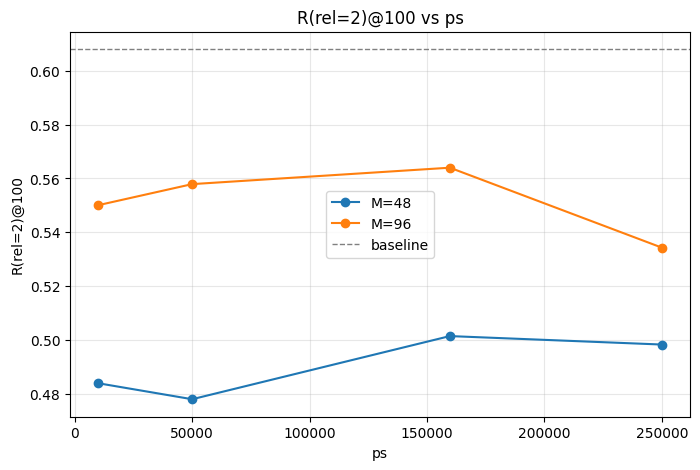

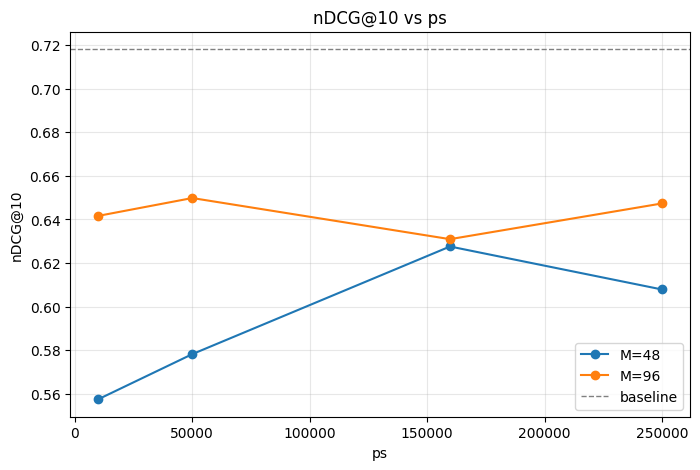

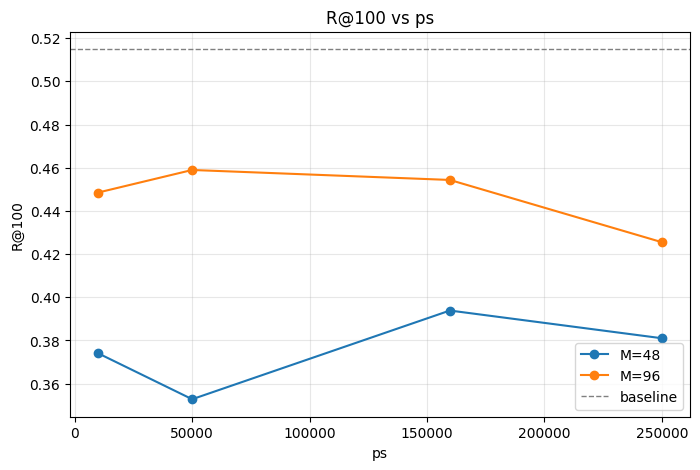

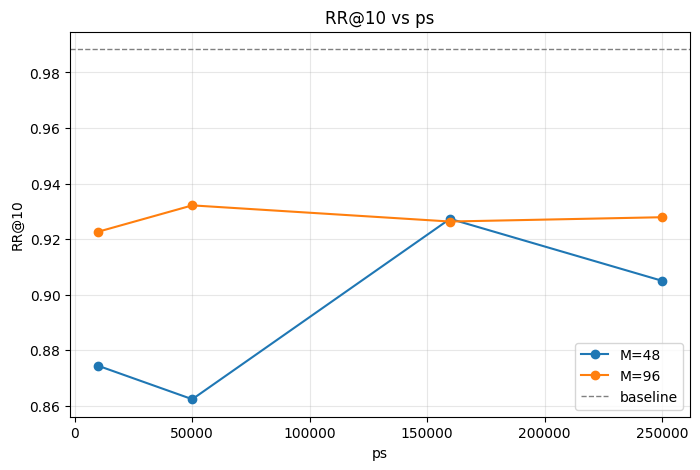

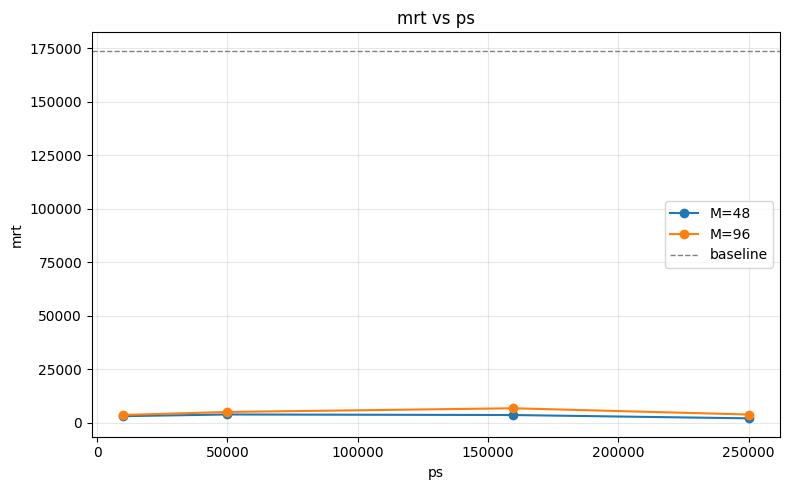

In [21]:
df = collect_all_results(Path('pqss/'), split='2019')

# One figure per metric
metrics = ["R(rel=2)@100", "nDCG@10", "R@100", "RR@10", "mrt"]
for metric in metrics:
    if metric not in df.columns:
        print(f"[WARN] Metric {metric} not found in dataframe columns.")
        continue
    plot_summary(df, metric)

plt.tight_layout()
plt.show()